In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

df = pd.read_csv("D:/DATA/aitpune/college study thingy/dsbdal/prac_exam_questions/19-linear-boston/BostonHousing.csv")

df.head()

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,medv
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2


In [4]:
df.isnull().sum()

crim       0
zn         0
indus      0
chas       0
nox        0
rm         0
age        0
dis        0
rad        0
tax        0
ptratio    0
b          0
lstat      0
medv       0
dtype: int64

In [5]:
# Handle missing values
df = df.fillna(df.mean(numeric_only=True))

In [6]:
y = df["medv"]
X = df.drop("medv", axis=1)


--- Feature: crim ---
MSE: 61.69413745566079
RMSE: 7.854561569919787
R2: 0.15872146782902874


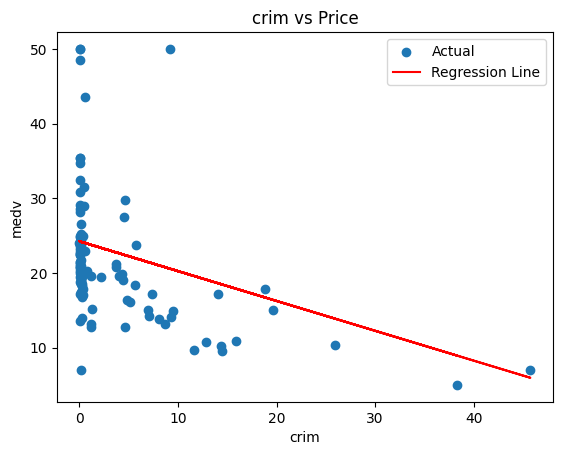


--- Feature: zn ---
MSE: 54.34745382306917
RMSE: 7.372072559536373
R2: 0.25890290285100526


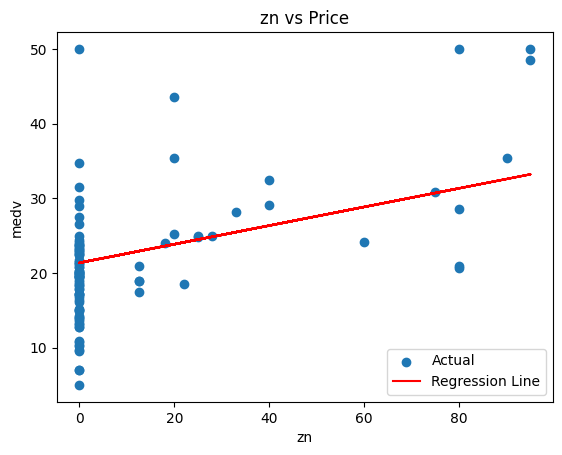


--- Feature: indus ---
MSE: 53.06374453858558
RMSE: 7.284486566573212
R2: 0.2764079220817347


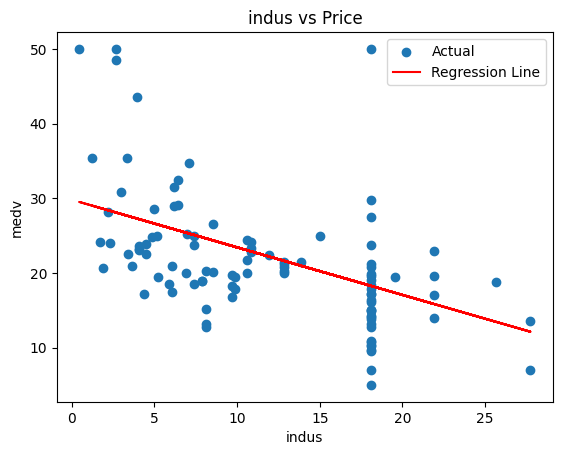


--- Feature: chas ---
MSE: 74.73440525330909
RMSE: 8.644906318365114
R2: -0.019099275022046447


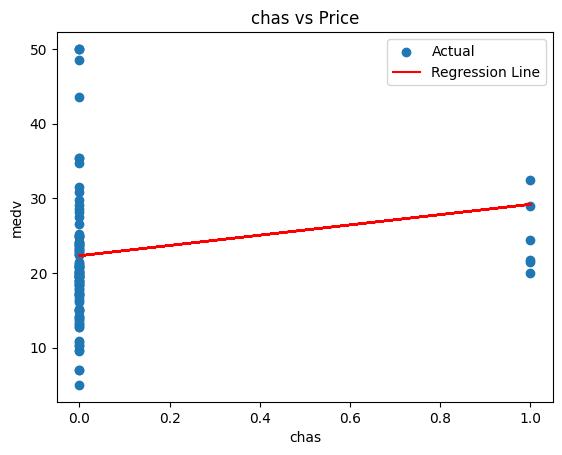


--- Feature: nox ---
MSE: 58.2853259323976
RMSE: 7.63448268924605
R2: 0.20520497619802724


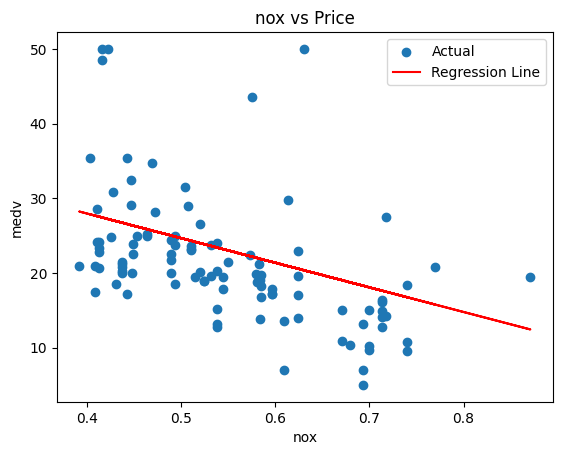


--- Feature: rm ---
MSE: 46.144775347317264
RMSE: 6.792994578778734
R2: 0.3707569232254778


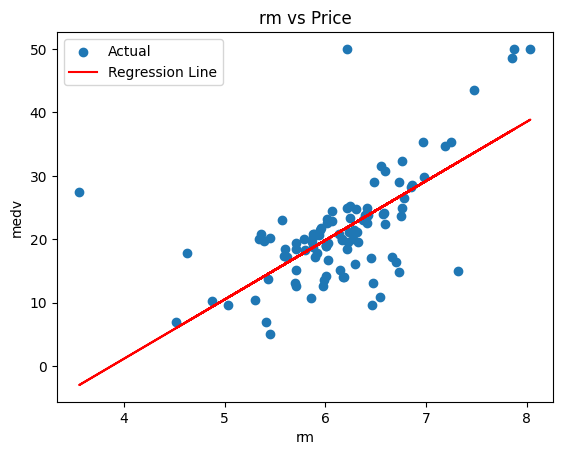


--- Feature: age ---
MSE: 55.73258162067601
RMSE: 7.465425749458366
R2: 0.24001491237901984


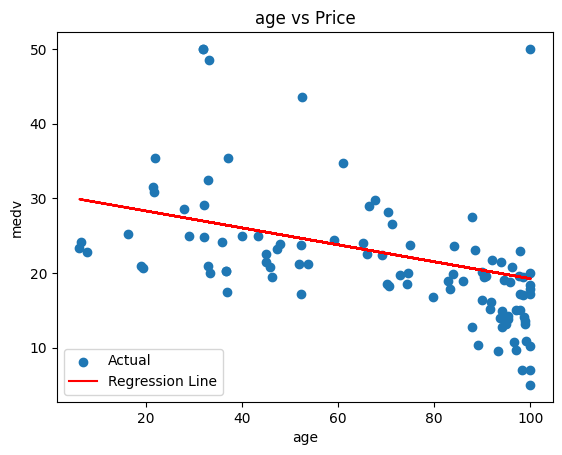


--- Feature: dis ---
MSE: 67.95691932803946
RMSE: 8.243598687954155
R2: 0.07332042069244615


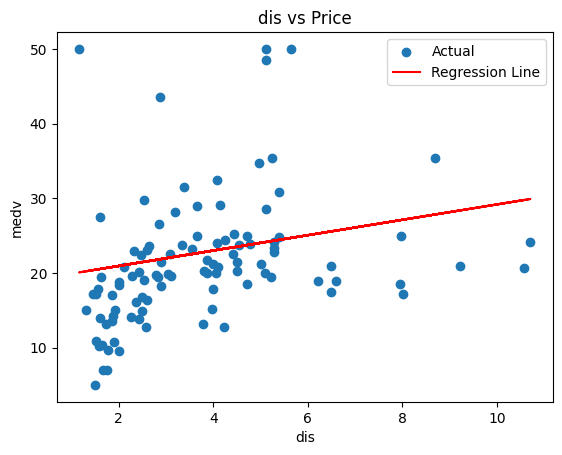


--- Feature: rad ---
MSE: 65.65174251079493
RMSE: 8.102576288489663
R2: 0.10475445720198939


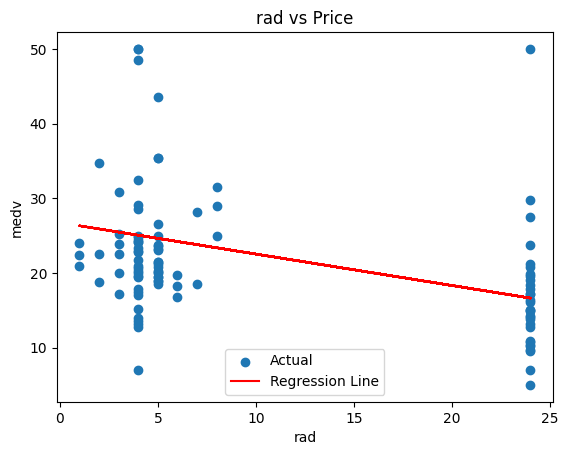


--- Feature: tax ---
MSE: 55.63802986480275
RMSE: 7.459090418060553
R2: 0.2413042465957823


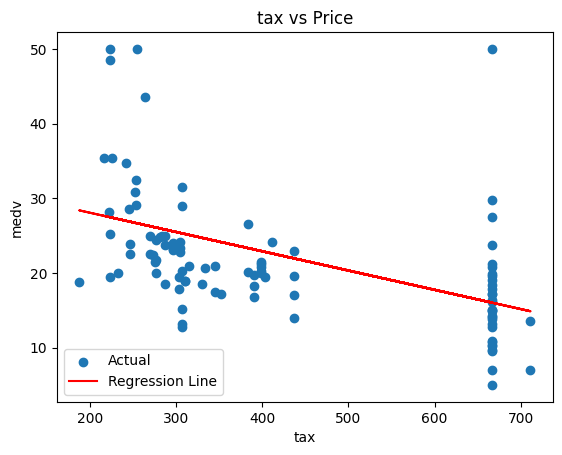


--- Feature: ptratio ---
MSE: 49.97637788483697
RMSE: 7.0693972787527635
R2: 0.3185081182082454


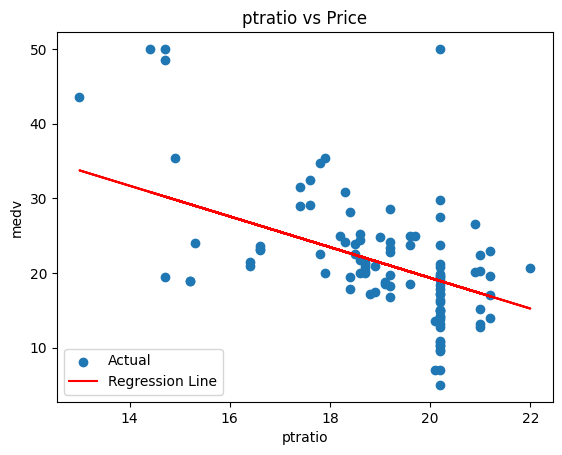


--- Feature: b ---
MSE: 68.31741207661821
RMSE: 8.26543477843835
R2: 0.06840464063797058


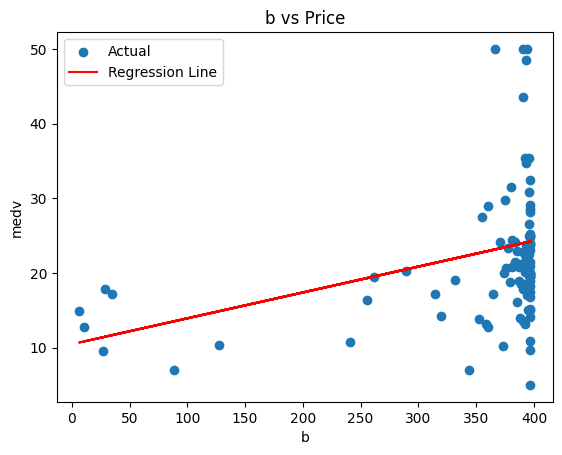


--- Feature: lstat ---
MSE: 33.51954917268489
RMSE: 5.789606996393182
R2: 0.5429180422970384


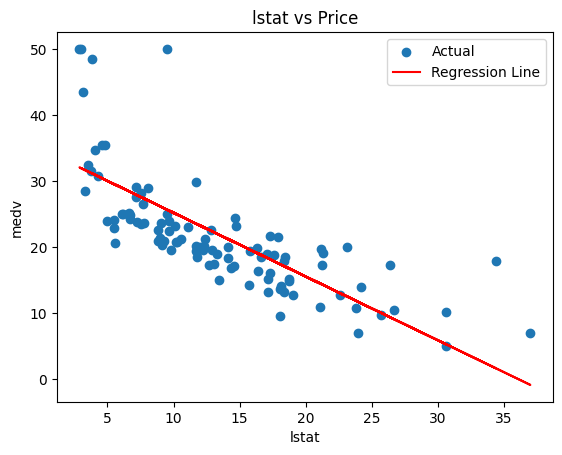

In [7]:
simple_mse_results = {}

for col in X.columns:
    
    print(f"\n--- Feature: {col} ---")
    
    X_single = X[[col]]
    
    X_train, X_test, y_train, y_test = train_test_split(
        X_single, y, test_size=0.2, random_state=42
    )
    
    model = LinearRegression()
    model.fit(X_train, y_train)
    
    y_pred = model.predict(X_test)
    
    # Metrics
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)
    
    simple_mse_results[col] = mse
    
    print("MSE:", mse)
    print("RMSE:", rmse)
    print("R2:", r2)
    
    # Visualization
    plt.figure()
    plt.scatter(X_test, y_test, label="Actual")
    plt.plot(X_test, y_pred, color='red', label="Regression Line")
    
    plt.xlabel(col)
    plt.ylabel("medv")
    plt.title(f"{col} vs Price")
    plt.legend()
    
    plt.show()

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model_multi = LinearRegression()
model_multi.fit(X_train, y_train)

y_pred_multi = model_multi.predict(X_test)

In [9]:
mse_multi = mean_squared_error(y_test, y_pred_multi)
rmse_multi = np.sqrt(mse_multi)
r2_multi = r2_score(y_test, y_pred_multi)

print("\nMultiple Linear Regression")
print("MSE:", mse_multi)
print("RMSE:", rmse_multi)
print("R2:", r2_multi)


Multiple Linear Regression
MSE: 24.291119474973538
RMSE: 4.928602182665339
R2: 0.6687594935356317


In [10]:
print("\nBest Simple Model (Lowest MSE):")
best_feature = min(simple_mse_results, key=simple_mse_results.get)
print(best_feature, "→ MSE:", simple_mse_results[best_feature])

print("\nMultiple Linear Regression MSE:", mse_multi)


Best Simple Model (Lowest MSE):
lstat → MSE: 33.51954917268489

Multiple Linear Regression MSE: 24.291119474973538


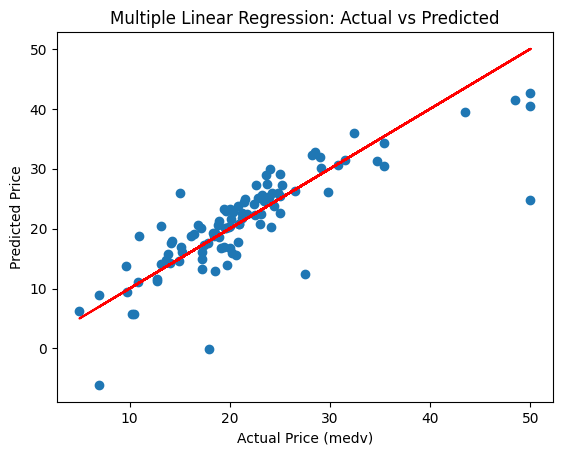

In [12]:
plt.figure()

plt.scatter(y_test, y_pred_multi)

plt.plot(
    y_test, y_test,
    color='red'
)

plt.xlabel("Actual Price (medv)")
plt.ylabel("Predicted Price")
plt.title("Multiple Linear Regression: Actual vs Predicted")

plt.show()